In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
import diffrax
from jaxtyping import Float

import dismech_jax as djx

from util import TripletModel, validate_model, train_model, get_base_rod
from animate import animate

jax.config.update("jax_enable_x64", True)


In [2]:
class MLP(eqx.Module):
    layer1: eqx.nn.Linear
    layer2: eqx.nn.Linear

    def __init__(self, in_features: int, hidden_size: int, out_features: int, key: jax.Array):
        key1, key2 = jax.random.split(key)
        self.layer1 = eqx.nn.Linear(in_features, hidden_size, key=key1)
        self.layer2 = eqx.nn.Linear(hidden_size, out_features, key=key2)

        # small initialization
        self.layer1 = eqx.tree_at(
            lambda l: l.weight, self.layer1, self.layer1.weight * 1e-2
        )
        self.layer2 = eqx.tree_at(
            lambda l: l.weight, self.layer2, self.layer2.weight * 1e-2
        )

    def __call__(self, x: jax.Array) -> jax.Array:
        # x should have shape (5,)
        x = jax.nn.softplus(self.layer1(x))
        x = self.layer2(x)
        return jax.nn.softplus(x)   # shape (2,), always positive


class Example(TripletModel):
    K: jax.Array
    mlp: MLP

    def __init__(self, der_K: jax.Array, key: jax.Array):
        self.K = der_K
        self.mlp = MLP(in_features=5, hidden_size=10, out_features=2, key=key)

    def get_K(self, del_strain: Float[jax.Array, "5"]) -> Float[jax.Array, "2"]:
        del_strain = jnp.ravel(del_strain)

        K_base = jax.nn.softplus(self.K)   # positive base
        # K_base = self.K   # positive base, but not enforced to be positive --- IGNORE ---
        dK = self.mlp(del_strain)          # positive correction
        # return K_base*(1 + dK)                 # total positive K
        return dK + K_base                 # total positive K, with a skip connection --- IGNORE ---

    def __call__(self, del_strain: Float[jax.Array, "5"]) -> Float[jax.Array, ""]:
        K = self.get_K(del_strain)

        stretching_energy = 0.5 * (
            K[0] * del_strain[0]**2 +
            K[0] * del_strain[1]**2
        )
        bending_energy = 0.5 * (
            K[1] * del_strain[3]**2
        )

        return stretching_energy + bending_energy



In [3]:
from util import TestCase

train_file = "output.npz"
valid_file = "output_valid.npz"

# validate_model(Example)

final_model, init_K, train_history, valid_history = train_model(Example, key=jax.random.PRNGKey(42), train_file=train_file, valid_file=valid_file, n_epochs=500, lr=1e-2, init_K=jnp.array([2.0, 0.02]) )
# final_model, train_history, valid_history = train_model(Example, key=jax.random.PRNGKey(42), train_file="output_valid.npz", valid_file="output_valid.npz", n_epochs=100, lr=1e-2)

print( "initial K: ", init_K)
print( "learned K: ", final_model.K)

Step 0    | LR: 1.000e-02  | Train: 1.00648e-03  | Valid: 1.78153e-03  | K: [1.99000105 0.01000054]
Step 10   | LR: 9.991e-03  | Train: 7.62077e-04  | Valid: 1.48845e-03  | K: [ 1.88875983 -0.09125637]
Step 20   | LR: 9.965e-03  | Train: 5.28850e-04  | Valid: 1.20350e-03  | K: [ 1.78269399 -0.1973225 ]
Step 30   | LR: 9.921e-03  | Train: 3.95828e-04  | Valid: 1.08049e-03  | K: [ 1.67202307 -0.30780541]
Step 40   | LR: 9.859e-03  | Train: 3.17042e-04  | Valid: 1.02668e-03  | K: [ 1.56015518 -0.41849996]
Step 50   | LR: 9.781e-03  | Train: 2.53867e-04  | Valid: 7.44737e-04  | K: [ 1.44981172 -0.52589312]
Step 60   | LR: 9.685e-03  | Train: 1.98354e-04  | Valid: 7.29693e-04  | K: [ 1.34275415 -0.62807302]
Step 70   | LR: 9.573e-03  | Train: 1.49976e-04  | Valid: 6.41839e-04  | K: [ 1.24057226 -0.72383456]
Step 80   | LR: 9.446e-03  | Train: 1.09372e-04  | Valid: 6.33827e-04  | K: [ 1.14505123 -0.81216991]
Step 90   | LR: 9.302e-03  | Train: 7.70423e-05  | Valid: 5.92981e-04  | K: [ 1.0582

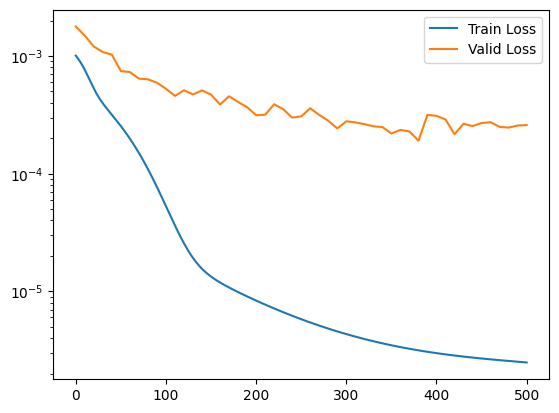

In [4]:
import matplotlib.pyplot as plt
train_np = np.asarray(train_history, dtype=float).reshape(-1)
valid_np = np.asarray(valid_history, dtype=float).reshape(-1)

idx_valid = np.where(valid_np != -1)[0]

plt.plot(np.arange(train_np.size), train_np, label="Train Loss")
plt.plot(idx_valid, valid_np[idx_valid], label="Valid Loss")
plt.yscale("log")
plt.legend()
plt.show()

In [5]:
train = TestCase.from_npz(train_file)
valid = TestCase.from_npz(valid_file)
# train = TestCase.from_npz("output_valid.npz")
# valid = TestCase.from_npz("output_valid.npz")
print("Train:")
print("fixed idx:", train.bc.idx_b)
print("slope:", train.bc.xb_m)
print("intercept:", train.bc.xb_c)
print("Valid:")
print("fixed idx:", valid.bc.idx_b)
print("slope:", valid.bc.xb_m)
print("intercept:", valid.bc.xb_c)
lambdas = jnp.linspace(0.0, 1.0, valid.qs.shape[0])


Train:
fixed idx: [ 0  1  2  3  7  8  9 10]
slope: [[0.  0.  0.  0.  0.  0.5 0.  0. ]]
intercept: [0.  0.  0.  0.  0.  0.5 0.  0. ]
Valid:
fixed idx: [ 0  1  2  3  7  8  9 10]
slope: [[ 0.   0.   0.   0.   0.  -0.1  0.   0. ]]
intercept: [0.  0.  0.  0.  0.  0.5 0.  0. ]


In [6]:

base, aux, _ = get_base_rod()
rods = base.with_bc(valid.bc)
pred = rods.solve(final_model, lambdas, aux, max_dlambda=5e-3, iters=5, ls_steps=10)[0]
animate(pred)

In [7]:
animate(valid.qs)

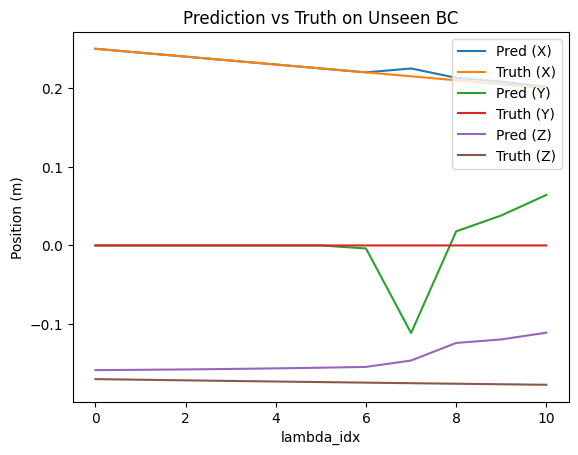

In [8]:
import matplotlib.pyplot as plt

plt.plot(pred[:, 4], label="Pred (X)")
plt.plot(valid.qs[:, 4], label="Truth (X)")
plt.plot(pred[:, 5], label="Pred (Y)")
plt.plot(valid.qs[:, 5], label="Truth (Y)")
plt.plot(pred[:, 6], label="Pred (Z)")
plt.plot(valid.qs[:, 6], label="Truth (Z)")
plt.legend()
plt.title("Prediction vs Truth on Unseen BC")
plt.xlabel("lambda_idx")
plt.ylabel("Position (m)")
plt.show()

In [9]:
print("Training BC:")
print("init: ", train.qs[0, 8:11])
print("final: ", train.qs[-1, 8:11])

print("Validation BC:")
print("init: ", valid.qs[0, 8:11])
print("final: ", valid.qs[-1, 8:11])

Training BC:
init:  [0.5 0.  0. ]
final:  [1. 0. 0.]
Validation BC:
init:  [0.5 0.  0. ]
final:  [0.4 0.  0. ]


In [10]:
print("initial position of the middle node in the training data: ", train.qs[0, 4:7])
print("final position of the middle node in the training data: ", train.qs[-1, 4:7])

initial position of the middle node in the training data:  [ 2.50000000e-01  3.61652220e-12 -1.69941712e-01]
final position of the middle node in the training data:  [ 4.99999146e-01 -9.07533152e-06 -1.23843111e-01]


In [11]:
print("initial position of the middle node in the validation data: ", valid.qs[0, 4:7])
print("final position of the middle node in the validation data: ", valid.qs[-1, 4:7])

initial position of the middle node in the validation data:  [ 2.50000000e-01  3.61652220e-12 -1.69941712e-01]
final position of the middle node in the validation data:  [ 2.00012391e-01  5.71156971e-06 -1.77130449e-01]


In [12]:
print("initial position of the middle node in the prediction: ", pred[0, 4:7])
print("final position of the middle node in the prediction: ", pred[-1, 4:7])

initial position of the middle node in the prediction:  [ 2.50000093e-01 -1.33504677e-05 -1.58472849e-01]
final position of the middle node in the prediction:  [ 0.20165583  0.06422687 -0.1109237 ]
